## Preamble

In [2]:
# dependencies.
import sys
import ast
import logging
from pathlib import Path

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error, mean_poisson_deviance,
    r2_score, mean_squared_error
)


# initialize logger.
log = logging.getLogger(__name__)
log.addHandler(logging.StreamHandler(stream=sys.stdout))
log.setLevel(logging.INFO)

log.info("Log initialized.")

# set seed.
RANDOM_SEED = 4890
np.random.seed(RANDOM_SEED)

# directories.
DATA_DIR = Path("../_data").resolve()
OUTPUT_DIR = Path("../output").resolve()

# load training data.
df_train = pd.read_csv(DATA_DIR / "train_encoded.csv")

# load feature selections from variable clustering.
feat_select = pd.read_csv(OUTPUT_DIR / "varreduction_stats.csv")

# keep selected features.
threshold_select = 99
features = list(ast.literal_eval(feat_select.loc[
    feat_select["threshold"] == threshold_select, 
    "selected_vars"
].iloc[0]))

df_train["claim_sev"] = df_train.apply(
    lambda row: row["claimcst0"] / row["numclaims"] if row["numclaims"] != 0 else np.nan,
    axis=1
)
df_train = df_train[features + ["clm", "numclaims", "claimcst0", "sample", "id", "claim_sev"]]

# split by sample.
train = df_train[df_train["sample"] == "1|bld"].copy()
validate = df_train[df_train["sample"] == "2|val"].copy()

Log initialized.


## XGBoost

### Utils

In [3]:
def log_reg_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                    label: str = "", freq_model: bool = False) -> None:
    """Logs regression metrics."""
    
    log.info(f"\n{'='*80}")
    log.info(f"Regression Results: {label}")
    log.info(f"{'-'*80}")
    
    log.info(f"N: {len(y_true)}")
    log.info(f"RMSE: {root_mean_squared_error(y_true=y_true, y_pred=y_pred)}")
    log.info(f"MSE: {mean_squared_error(y_true=y_true, y_pred=y_pred)}")
    log.info(f"MAE: {mean_absolute_error(y_true=y_true, y_pred=y_pred)}")
    log.info(f"R2: {r2_score(y_true=y_true, y_pred=y_pred)}")
    
    non_zero = y_true != 0
    if non_zero.sum() > 0:
        mape = np.mean(np.abs(
            (y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero]
        )) * 100
        log.info(f"MAPE: {mape}%")
    else:
        log.info("MAPE: N/A")
        
    if freq_model:
        y_pred_pos = np.maximum(y_pred, 1e-10)
        poisson_dev = mean_poisson_deviance(y_true=y_true, y_pred=y_pred_pos)
        print(f"Poisson Deviance: {poisson_dev}")
    
    print(f"Mean Actual: {y_true.mean()}")
    print(f"Mean Predicted: {y_pred.mean()}")
    
    log.info(f"{'='*80}\n")
    
    return None

### Frequency Model

In [ ]:
# splits/arrays.
x_train_freq = train[features].copy()
y_train_freq = train["numclaims"].copy()
x_validate_freq = validate[features].copy()
y_validate_freq = validate["numclaims"].copy()

# create model.
xgb_reg = xgb.XGBRegressor(
    objective="count:poisson",
    eval_metric="poisson-nloglik",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="auto"
)

param_freq = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 6, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [50, 100, 150],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1.0, 2.0, 5.0],
    "gamma": [0, 0.1, 0.2]
}

freq_hyper = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_freq,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
freq_hyper.fit(X=x_train_freq, y=y_train_freq)

log.info(f"\n\nBest hyper-parameters: {freq_hyper.best_params_}")

# validation metrics & featrue import.
freq_model: xgb.XGBRegressor = freq_hyper.best_estimator_   # type: ignore

y_freq_pred_train = freq_model.predict(x_train_freq)
log_reg_metrics(
    y_true=np.array(y_train_freq.values), 
    y_pred=y_freq_pred_train, 
    label="Frequency Model - Training Set",
    freq_model=True
)

y_freq_pred_validate = freq_model.predict(x_validate_freq)
log_reg_metrics(
    y_true=np.array(y_validate_freq.values), 
    y_pred=y_freq_pred_validate,
    label="Frequency Model - Validation Set",
    freq_model=True
)

freq_importance = pd.DataFrame({
    "feature": features,
    "importance": freq_model.feature_importances_
})
freq_importance = freq_importance.sort_values("importance", ascending=False)
log.info(
    "\nTop 10 Feature Importance (Frequency model):\n"
    f"{freq_importance.head(10)}"
)

# export.
freq_model.save_model(OUTPUT_DIR / "xgboost_freq_model.json")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Best hyper-parameters: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 50, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}

Regression Results: Frequency Model - Training Set
--------------------------------------------------------------------------------
N: 11204
RMSE: 0.26993241906166077
MSE: 0.07286350429058075
MAE: 0.13329201936721802
R2: 0.008259057998657227
MAPE: 92.5604194499834%
Poisson Deviance: 0.3797069489955902
Mean Actual: 0.07184933952159943
Mean Predicted: 0.07189780473709106


Regression Results: Frequency Model - Validation Set
--------------------------------------------------------------------------------
N: 3796
RMSE: 0.27147701382637024
MSE: 0.07369977235794067
MAE: 0.13296052813529968
R2: 0.0036725997924804688
MAPE: 92.83276925995654%
Poisson Deviance: 0.3832800090312958
Mean Actual: 0.07112750263435196
Mean Predicted: 0.071763

---

### Severity Model

In [8]:
# Only want positive claims.
train_sev = train.dropna(subset=["claim_sev"]).copy()
validate_sev = validate.dropna(subset=["claim_sev"]).copy()

# splits/arrays.
x_train_sev = train_sev[features].copy()
y_train_sev = train_sev["claim_sev"].copy()
x_validate_sev = validate_sev[features].copy()
y_validate_sev = validate_sev["claim_sev"].copy()

# create model.
xgb_sev = xgb.XGBRegressor(
    objective="reg:gamma",
    eval_metric="gamma-nloglik",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="auto"
)

param_sev = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.05, 0.1, 0.5],
    "reg_lambda": [1.0, 2.0, 5.0],
    "gamma": [0, 0.1, 0.2, 0.5]
}

sev_hyper = RandomizedSearchCV(
    estimator=xgb_sev,
    param_distributions=param_sev,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

sev_hyper.fit(X=x_train_sev, y=y_train_sev)

log.info(f"\n\nBest hyper-parameters: {sev_hyper.best_params_}")

# validation metrics & feature import.
sev_model: xgb.XGBRegressor = sev_hyper.best_estimator_ # type: ignore

y_sev_pred_train = sev_model.predict(x_train_sev)
log_reg_metrics(
    y_true=y_train_sev.values, 
    y_pred=y_sev_pred_train, 
    label="Severity Model - Training Set"
)

y_sev_pred_validate = sev_model.predict(x_validate_sev)
log_reg_metrics(
    y_true=y_validate_sev.values, 
    y_pred=y_sev_pred_validate, 
    label="Severity Model - Validation Set"
)

sev_importance = pd.DataFrame({
    "feature": features,
    "importance": sev_model.feature_importances_
})
sev_importance = sev_importance.sort_values("importance", ascending=False)

log.info(
    "\nTop 10 Feature Importance (Severity model):\n"
    f"{sev_importance.head(10)}"  # ✅ Fixed variable name
)

# export.
sev_model.save_model(OUTPUT_DIR / "xgboost_sev_model.json")


Fitting 5 folds for each of 50 candidates, totalling 250 fits




Best hyper-parameters: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0.05, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}

Regression Results: Severity Model - Training Set
--------------------------------------------------------------------------------
N: 767
RMSE: 4571.903904236914
MSE: 20902305.30957674
MAE: 3173.530692560198
R2: 0.23823458834934297
MAPE: 61.06512041700345%
Mean Actual: 6561.753229076271
Mean Predicted: 6017.74560546875


Regression Results: Severity Model - Validation Set
--------------------------------------------------------------------------------
N: 255
RMSE: 5936.8394719245125
MSE: 35246062.91540093
MAE: 4218.739501317157
R2: -0.04371273901496786
MAPE: 77.4480055711325%
Mean Actual: 7044.301619217647
Mean Predicted: 5990.779296875


Top 10 Feature Importance (Severity model):
                feature  importance
13      veh_color_brown    0.033362
31               area_a    0.032

### Combined Model

In [9]:

# predict on full dataset.
freq_pred_train_full = freq_model.predict(x_train_freq)
freq_pred_validate_full = freq_model.predict(x_validate_freq)

sev_pred_train_full = sev_model.predict(x_train_freq)
sev_pred_validate_full = sev_model.predict(x_validate_freq)

# calc. expected loss = frequency × severity
expected_loss_train = freq_pred_train_full * sev_pred_train_full
expected_loss_validate = freq_pred_validate_full * sev_pred_validate_full

# actual total claim cost.
actual_loss_train = np.array(train["claimcst0"].values)
actual_loss_validate = np.array(validate["claimcst0"].values)

# metrics.
combined_metrics_train = log_reg_metrics(
    y_true=actual_loss_train, 
    y_pred=expected_loss_train, 
    label="Combined Model - Training Set"
)

combined_metrics_val = log_reg_metrics(
    y_true=actual_loss_validate, 
    y_pred=expected_loss_validate, 
    label="Combined Model - Validation Set"
)

# calc. premium
prem_actual_val = np.array(actual_loss_validate)
prem_pred_val = np.array(expected_loss_validate)

log.info(f"\n{'='*80}")
log.info("Premium Statistics:")
log.info(f"{'-'*80}")
log.info(f"Actual Mean: ${round(prem_actual_val.mean(), 2)}")
log.info(f"Predicted Mean: ${round(prem_pred_val.mean(), 2)}")
log.info(f"Acutal Median: ${np.median(prem_actual_val)}")
log.info(f"Predicted Median: ${np.median(prem_pred_val)}")
log.info(f"{'='*80}\n")

# export.
sev_model.save_model(OUTPUT_DIR / "xgboost_sev_model.json")


Regression Results: Combined Model - Training Set
--------------------------------------------------------------------------------
N: 11204
RMSE: 2255.9315021295615
MSE: 5089226.942300539
MAE: 838.4936582594536
R2: 0.012929481256642728
MAPE: 89.88099093245843%
Mean Actual: 471.82733843243483
Mean Predicted: 429.7784729003906


Regression Results: Combined Model - Validation Set
--------------------------------------------------------------------------------
N: 3796
RMSE: 2377.745155769113
MSE: 5653672.025783483
MAE: 861.3160584013494
R2: 0.001125501456658018
MAPE: 89.76423027687989%
Mean Actual: 492.0542510289779
Mean Predicted: 428.80706787109375


Premium Statistics:
--------------------------------------------------------------------------------
Actual Mean: $492.05
Predicted Mean: $428.80999755859375
Acutal Median: $0.0
Predicted Median: $418.80609130859375



## Inference

In [21]:
test_clean = pd.read_csv(DATA_DIR / "test_encoded.csv")

# Drop only fold/sample (id is needed later)
test_clean = test_clean.drop(columns=["fold", "sample"], errors='ignore')

# Reorder columns to match training
X_test = test_clean[features]

# Predict using final model
test_pred_freq = freq_model.predict(X_test)
test_pred_sev = sev_model.predict(X_test)
test_prem = test_pred_freq * test_pred_sev

# Create output DataFrame
output = test_clean.copy()
output["predicted_clm"] = test_pred_freq
output["predicted_sev"] = test_pred_sev
output["predicted_premium"] = test_prem

# Save result
output.to_csv("../output/xgboost_predictions_inference.csv", index=False)

output.sort_values(by=["predicted_premium"]).head(100).describe()

,id,veh_value,exposure,veh_age,agecat,max_power,driving_history_score,e_bill,trm_len,credit_score,low_education_ind,predicted_clm,predicted_sev,predicted_premium
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,10903.940000,6.24830,0.420318,2.490000,3.460000,94.54000,81.780000,0.620000,10.500000,655.619788,0.090000,0.062430,4482.933594,279.629791
std,5618.557486,0.56886,0.285506,0.893241,1.473126,24.55438,18.900901,0.487832,2.611165,5.763443,0.287623,0.002181,197.103210,10.443495
min,1038.000000,4.08000,0.022041,1.000000,1.000000,70.00000,55.000000,0.000000,6.000000,640.601704,0.000000,0.058728,4027.320801,246.630005
25%,6433.750000,5.96750,0.176873,2.000000,2.000000,80.75000,69.750000,0.000000,10.500000,652.743186,0.000000,0.060532,4379.969727,272.715073
50%,10608.000000,6.25000,0.370413,2.000000,4.000000,90.50000,80.000000,1.000000,12.000000,657.199327,0.000000,0.062537,4517.296875,282.781403
75%,15235.750000,6.65250,0.676317,3.000000,4.000000,98.50000,94.000000,1.000000,12.000000,659.716047,0.000000,0.063707,4616.572021,287.910736
max,21794.000000,7.37000,0.964742,4.000000,6.000000,221.00000,133.000000,1.000000,12.000000,664.415589,1.000000,0.069824,4903.060547,291.350647


## Figures

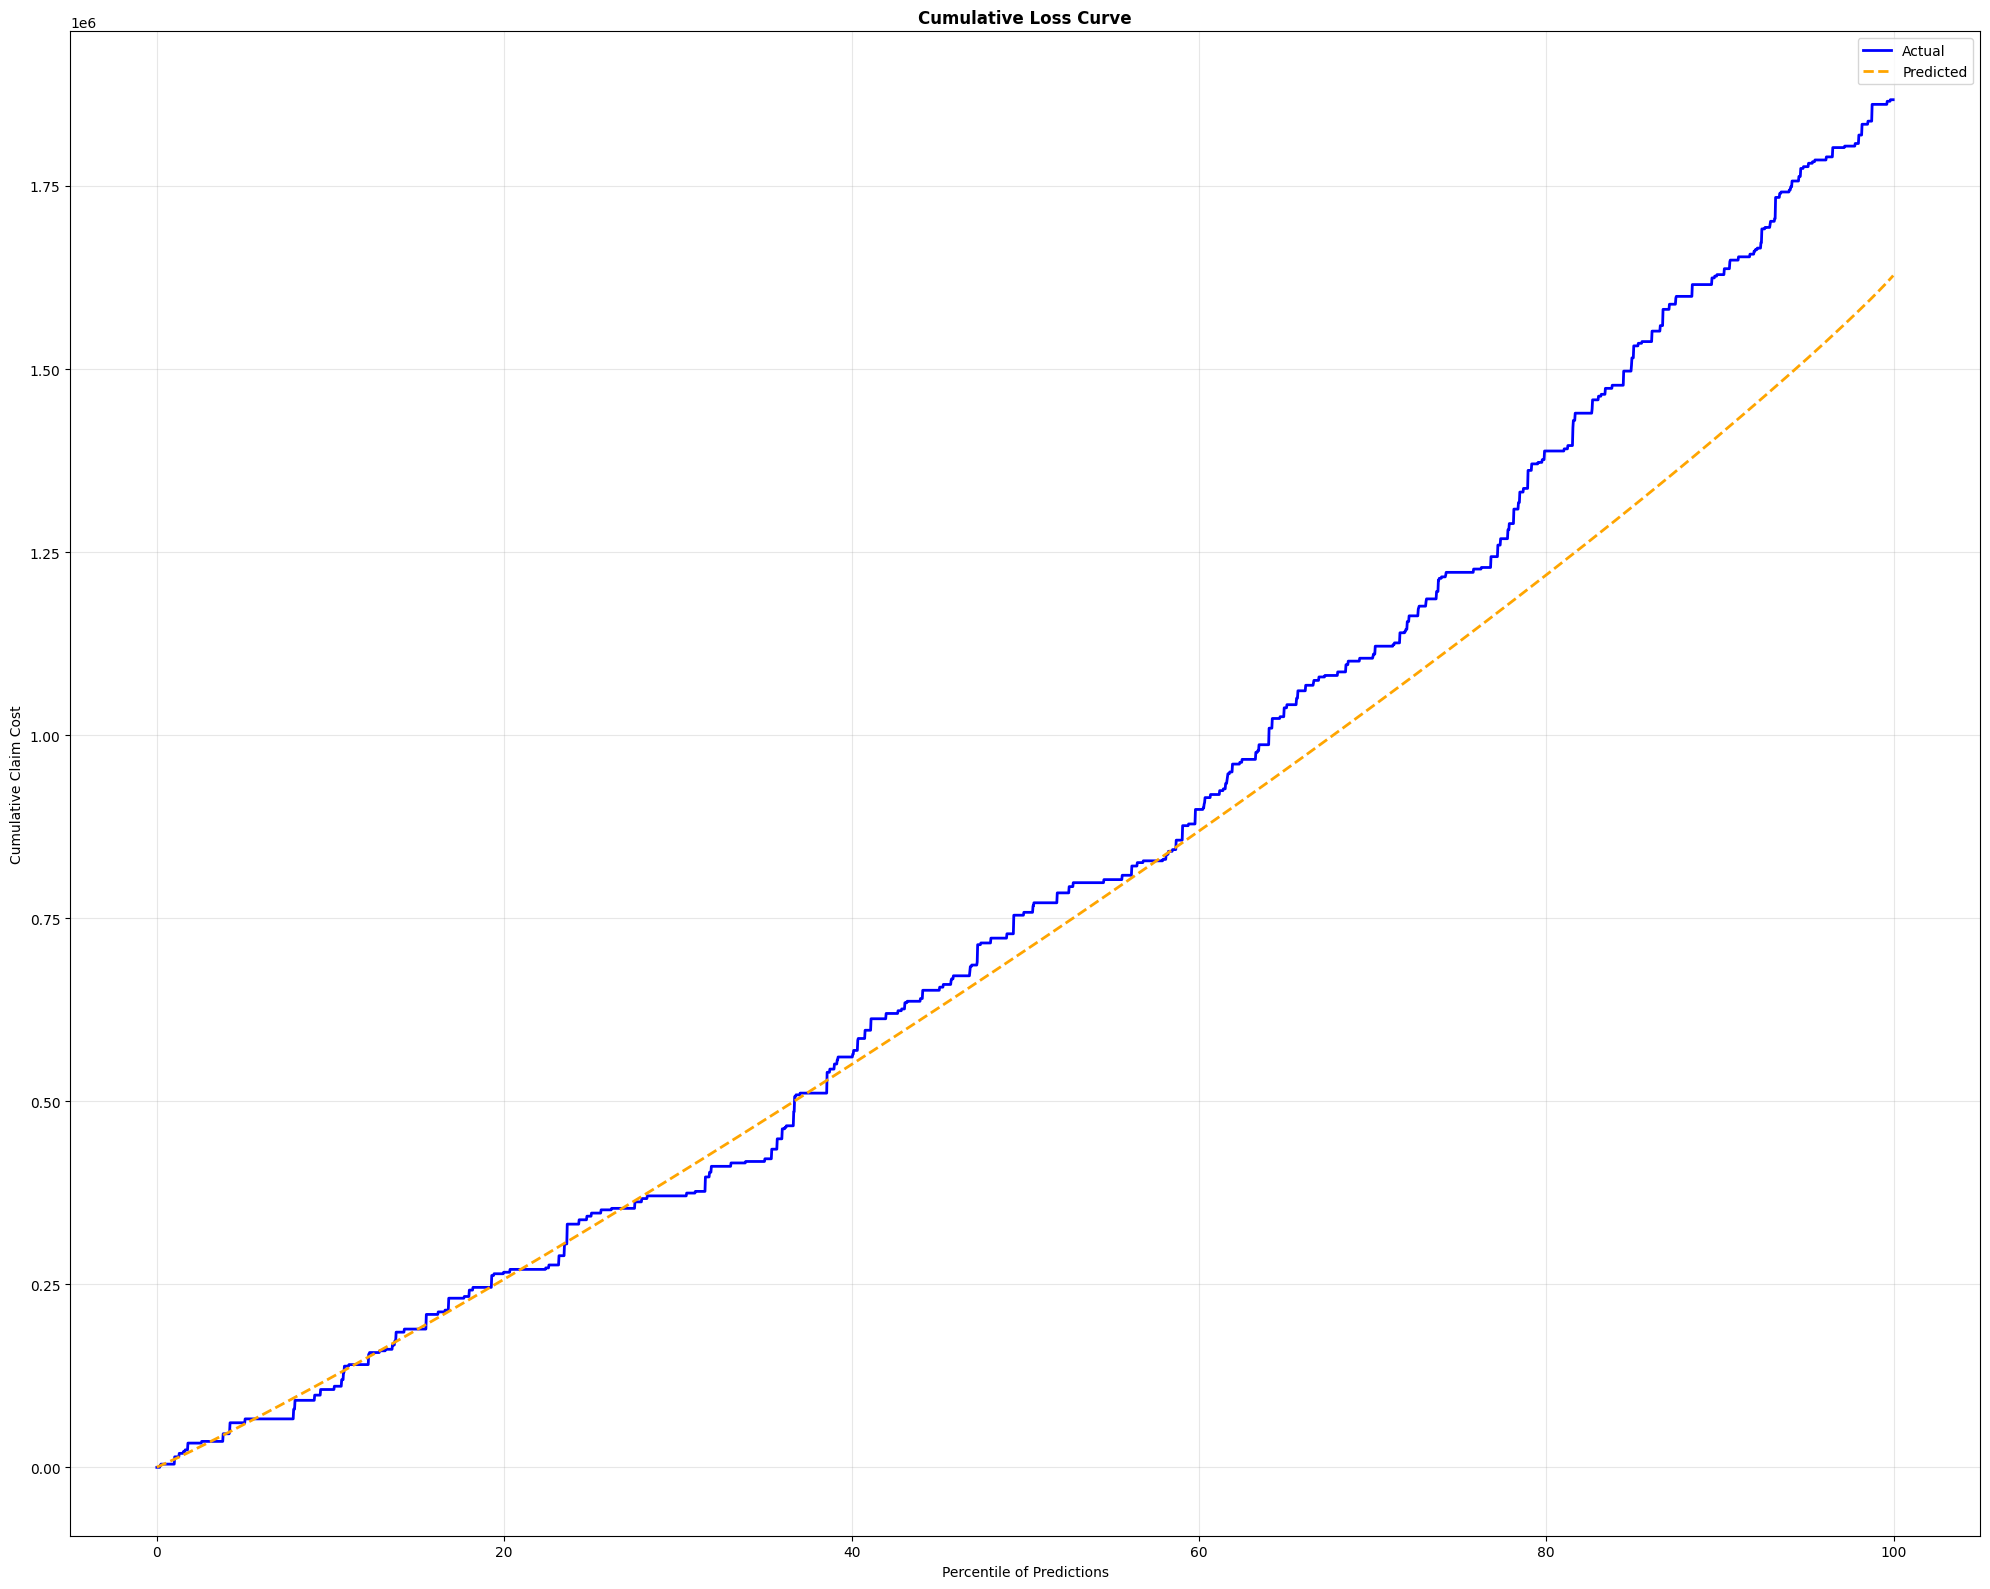

/var/folders/11/k9d6x4qd0qg7239m5p62lkkh0000gn/T/ipykernel_56821/1935720528.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes.boxplot(


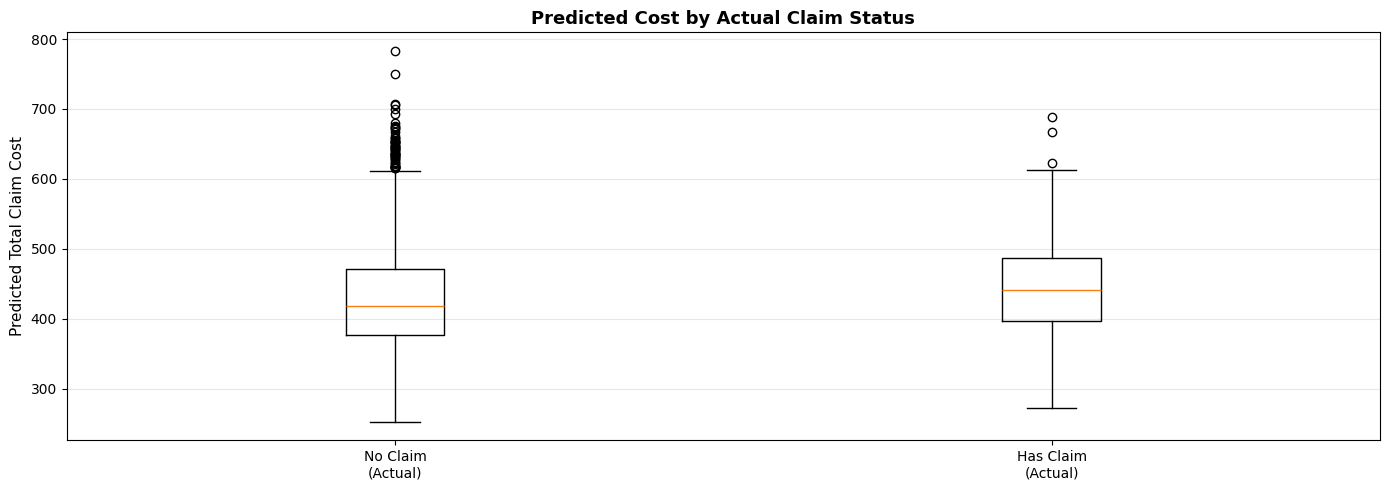

In [ ]:
fig = plt.figure(figsize=(20, 16))


# cummulative loss.
ax3 = plt.subplot(1, 1, 1)
sorted_indices = np.argsort(expected_loss_validate)
cumulative_actual = np.cumsum(actual_loss_validate[sorted_indices])
cumulative_pred = np.cumsum(expected_loss_validate[sorted_indices])
percentiles = np.arange(len(sorted_indices)) / len(sorted_indices) * 100
ax3.plot(
    percentiles, 
    cumulative_actual, 
    label="Actual", 
    linewidth=2, 
    color="blue"
)
ax3.plot(
    percentiles, 
    cumulative_pred, 
    label="Predicted", 
    linewidth=2, 
    linestyle="--", 
    color="orange"
)
ax3.set_xlabel(xlabel="Percentile of Predictions", fontsize=10)
ax3.set_ylabel(ylabel="Cumulative Claim Cost", fontsize=10)
ax3.set_title(label="Cumulative Loss Curve", fontsize=12, fontweight="bold")
ax3.legend()
ax3.grid(visible=True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_cumloss.png", dpi=600, bbox_inches="tight")
plt.show()

# prediction by claim stat.
fig2, axes = plt.subplots(2, 1, figsize=(14, 5))

has_claim = validate["clm"] == 1
no_claim = validate["clm"] == 0

has_claim = tes["clm"] == 1
no_claim = validate["clm"] == 0

axes[0].boxplot(
    [expected_loss_validate[no_claim], expected_loss_validate[has_claim]], 
    labels=["No Claim\n(Actual)", "Has Claim\n(Actual)"]
)
axes[0].set_ylabel("Predicted Total Claim Cost", fontsize=11)
axes[0].set_title("Predicted Cost by Actual Claim Status", fontsize=13, fontweight="bold")
axes[0].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_clmstat.png", dpi=600, bbox_inches="tight")
plt.show()

## SHAP

/var/folders/11/k9d6x4qd0qg7239m5p62lkkh0000gn/T/ipykernel_56821/2828189775.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_validate_sev, plot_type="bar")


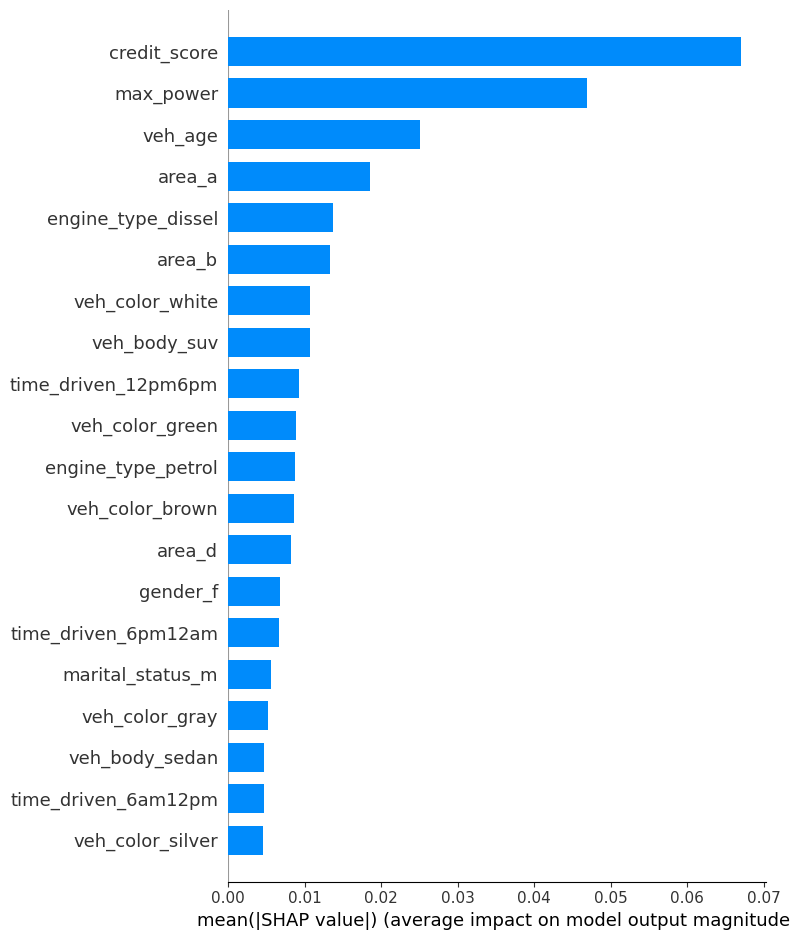

/var/folders/11/k9d6x4qd0qg7239m5p62lkkh0000gn/T/ipykernel_56821/2828189775.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_validate_sev)


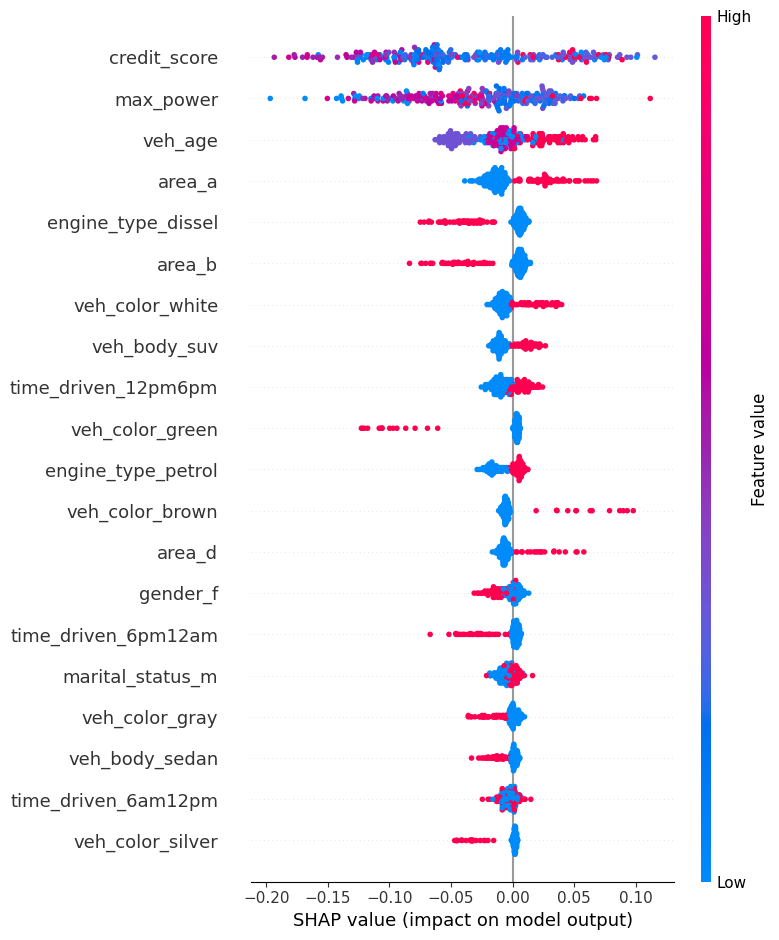

In [ ]:
import shap

# SHAP expects a small sample for speed
explainer = shap.TreeExplainer(sev_model)

# Use a subset of validation set to compute SHAP values
shap_values = explainer.shap_values(x_validate_sev)

# Global Variable Importance
shap.summary_plot(shap_values, x_validate_sev, plot_type="bar")

# SHAP Summary Plot (beeswarm)
shap.summary_plot(shap_values, x_validate_sev)